# Определение возраста покупателей

**Описание проекта:**

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

* Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
* Контролировать добросовестность кассиров при продаже алкоголя.

**Задача проекта:**

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

**План выполнения проекта:**

* Провести исследовательский анализ набора фотографий.
* Подготовить данные к обучению.
* Обучить нейронную сеть и рассчитать её качество.

Метрика качества - MAE.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import ResNet50

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345) 

Found 7591 validated image filenames.


In [3]:
display(labels.head())
display(labels.info())

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


None

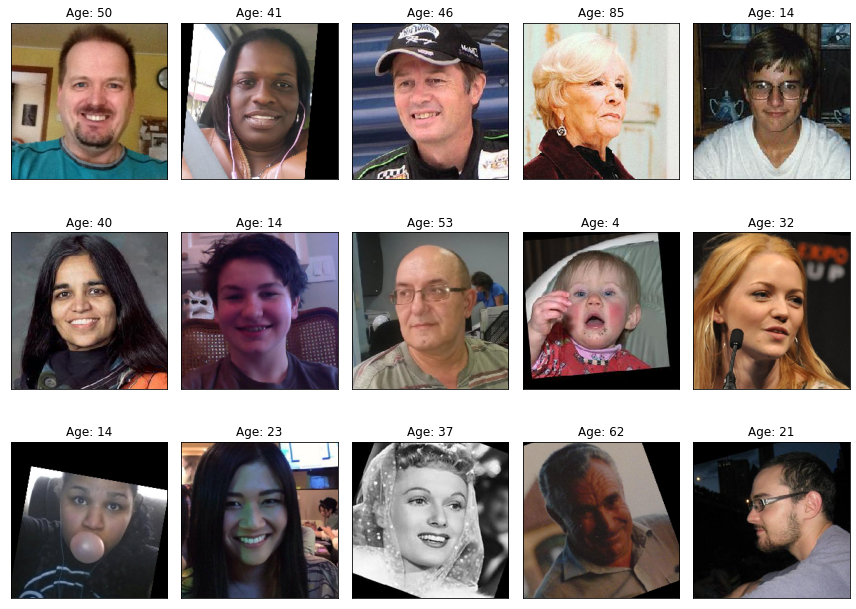

In [4]:
# Получаем первый батч из генератора
features, target = next(train_gen_flow)

# Выводим от 10 до 15 изображений
num_images_to_show = min(15, len(features)) # Чтобы не было ошибки, если в батче меньше 15 изображений

fig = plt.figure(figsize=(12, 10))  # увеличьте размер для лучшего просмотра
for i in range(num_images_to_show):
    fig.add_subplot(3, 5, i + 1)  # подгоните кол-во строк и столбцов под нужное кол-во изображений
    plt.imshow(features[i])
    plt.title(f"Age: {int(target[i])}")  # Добавляем заголовок с возрастом
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

### Промежуточный вывод:

Данные загружены, соответствуют описанию.

## Исследовательский анализ данных

Задачи исследовательского анализа данных:
* Посмотреть на размер выборки.
* Построить график распределения возраста в выборке.
* Сделать выводы.

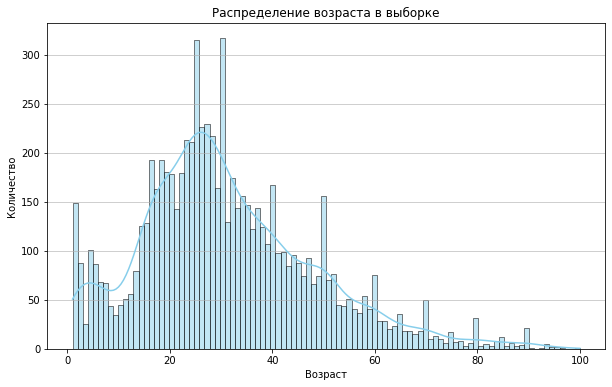

In [5]:
# Создаем гистограмму распределения возрастов
plt.figure(figsize=(10, 6))
sns.histplot(labels['real_age'], bins=100, kde=True, color='skyblue')
plt.title('Распределение возраста в выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [6]:
display('Среднее значение возраста: ', round(labels['real_age'].mean(), 2))
display('Медиана возраста: ', round(labels['real_age'].median(), 2))

'Среднее значение возраста: '

31.2

'Медиана возраста: '

29.0

### Промежуточные выводы:

* В датасете всего 7591 изображение, этого может оказаться мало.
* По графику распределения значений возраста наблюдается смещение влево. Это связано с "выбросами" пожилого возраста: мало кто доживает до таких лет, а новорождённых гораздо больше. Средний возраст достаточно молодой (31 год), медиана немного меньше (29 лет).
* Также по графику наблюдаются аномальные значения "юбилейных" возрастов. Вероятно, это связано с тем, что много фотографий было взято с празднований юбилеев, либо есть вероятность округления возрастов. Аномалии в районе 18 лет связаны, вероятно, с фотографиями каких-либо документов (паспорт, водительское удостоверение и т.п.). В то же время наблюдается провал в районе возраста 10 лет. Природу данного провала объяснить затруднительно.
* По выбранным для отображения фотографиям наблюдаются разные особенности: какие-то фотографии цветные, какие-то - чёрно-белые. Есть фотографии с частично перекрытым лицом, есть фотографии в профиль, есть экземпляры со слабым освещением. Также есть фотографии с присутствием других лиц на фоне, некоторые изображения наклонены под различными углами либо сдвинуты от центра. Наблюдается также различность размеров самих лиц: есть крупные и маленькие.

Эти проблемы могут привести к тому, что модель будет недостаточно корректно определять возраст, возможны перекосы в какую либо сторону, в области аномалий. 

**Заказчику рекомендуется доработать исходный датасет:** добавить фотографии для нивелирования аномалий, поработать над качественной составляющей датасета (светокоррекция, выравнивание и т.п.). 

Для исключения возможности недообучения или переобучения в текущих условиях необходима аугментация данных. Для того, чтобы не перегрузить модель, в даннойм случае ограничимся горизонтальными поворотами и масштабированием. Если будет необходимо, добавим ещё методы.

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import tensorflow as tf


def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, horizontal_flip=True, rescale=1./255)
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)
 
    return train_gen_flow
 
def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)
 
    return test_gen_flow
 
 
def create_model(input_shape):
 
    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
 
    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mae'])
 
 
    return model
 
 
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):
 
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)
 
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
 
    return model
```

## Вывод компилятора

```

Found 5694 validated image filenames.

Found 1897 validated image filenames.


<class 'tensorflow.python.keras.engine.sequential.Sequential'>


Train for 356 steps, validate for 119 steps

Epoch 1/10

356/356 - 98s - loss: 223.7119 - mae: 10.6958 - val_loss: 732.1664 - val_mae: 22.1126

Epoch 2/10

356/356 - 50s - loss: 85.3010 - mae: 7.0076 - val_loss: 147.8753 - val_mae: 9.5016

Epoch 3/10

356/356 - 52s - loss: 59.1956 - mae: 5.8962 - val_loss: 84.9362 - val_mae: 6.9359

Epoch 4/10

356/356 - 53s - loss: 43.5740 - mae: 5.0665 - val_loss: 74.9791 - val_mae: 6.4628

Epoch 5/10

356/356 - 54s - loss: 31.3846 - mae: 4.2779 - val_loss: 69.0048 - val_mae: 6.1875

Epoch 6/10

356/356 - 54s - loss: 25.9577 - mae: 3.8834 - val_loss: 72.4808 - val_mae: 6.3868

Epoch 7/10

356/356 - 56s - loss: 19.3549 - mae: 3.3643 - val_loss: 77.0324 - val_mae: 6.6024

Epoch 8/10

356/356 - 57s - loss: 16.4727 - mae: 3.1083 - val_loss: 72.6541 - val_mae: 6.2643

Epoch 9/10

356/356 - 55s - loss: 16.1522 - mae: 3.1024 - val_loss: 71.4461 - val_mae: 6.2436

Epoch 10/10

356/356 - 57s - loss: 14.3323 - mae: 2.8847 - val_loss: 66.0548 - val_mae: 5.9966



119/119 - 13s - loss: 66.0548 - mae: 5.9966

Test MAE: 5.9966


```

## Анализ обученной модели

Модель отлично справилась с заданием: на тестовом датасете метрика ниже необходимого порога. Возможно, если увеличить количество эпох, модель обучилась бы ещё лучше. Если у заказчика будет жедание, можно усложнить модель. 

Использование GPU и нейронных сетей позволяет быстро и эффективно обработать большое количество информации с высокой точностью.